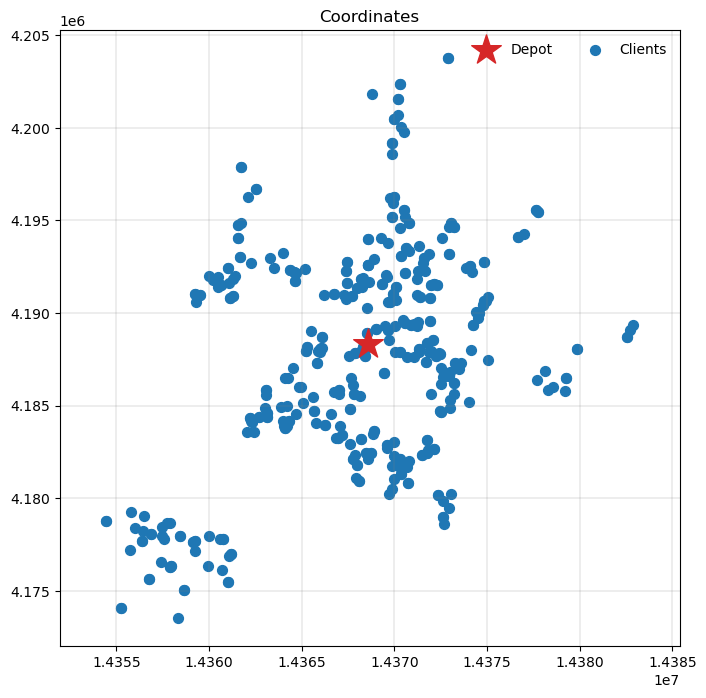

In [1]:
from pyvrp import Model
from pyvrp.stop import MaxRuntime
from pyproj import Transformer
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

df = pl.read_csv('/Users/jameslee/cj/cj_challenge/dataset/dataset_df.csv')
matrix = pl.read_csv("/Users/jameslee/cj/cj_challenge/dataset/matrix_df.csv")

truck_capacity = 160 * 280 * 180  

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
coords = [transformer.transform(lon, lat) for lon, lat in zip(df['Longitude'], df['Latitude'])]

m = Model()
m.add_vehicle_type(num_available=10, capacity=truck_capacity, fixed_cost=150000, unit_distance_cost=500)

index_to_order_number = []
index_to_location_name = []

depot = m.add_depot(x=coords[0][0], y=coords[0][1], name="Depot")
index_to_order_number.append(df['Order_Number'][0])
index_to_location_name.append("Depot")

for idx, row in enumerate(df.iter_rows(named=True)):
    if idx != 0:
        xs = coords[idx][0]
        ys = coords[idx][1]
        deliver = row['Volume']
        m.add_client(
            x=xs,
            y=ys,
            delivery=deliver,
            name=row['Destination']
        )
        index_to_order_number.append(row['Order_Number'])
        index_to_location_name.append(row['Destination'])

for frm in m.locations:
    for to in m.locations:
        origin = frm.name
        destination = to.name
        if origin != destination:
            distance = (matrix.filter((pl.col('ORIGIN') == origin) & (pl.col('DESTINATION') == destination))
                        .select('DISTANCE_METER').to_series().item()) / 1000
            m.add_edge(frm, to, distance=distance)
        else:
            m.add_edge(frm, to, distance=0)

import matplotlib.pyplot as plt
from pyvrp.plotting import plot_coordinates

_, ax = plt.subplots(figsize=(8, 8))
plot_coordinates(m.data(), ax=ax)

In [2]:
res = m.solve(stop=MaxRuntime(60), display=True)

PyVRP v0.11.3

Solving an instance with:
    1 depot
    437 clients
    10 vehicles (1 vehicle type)

                  |       Feasible        |      Infeasible
    Iters    Time |   #      Avg     Best |   #      Avg     Best
H     500     20s |  60  1018900   844000 |  55   863645   851500
H    1000     39s |  30   841433   837500 |  52   849837   844000
H    1500     58s |  38   837605   835500 |  52   900012   895560

Search terminated in 60.07s after 1569 iterations.
Best-found solution has cost 835500.

Solution results
    # routes: 5
     # trips: 5
   # clients: 437
   objective: 835500
    distance: 171
    duration: 0
# iterations: 1569
    run-time: 60.07 seconds



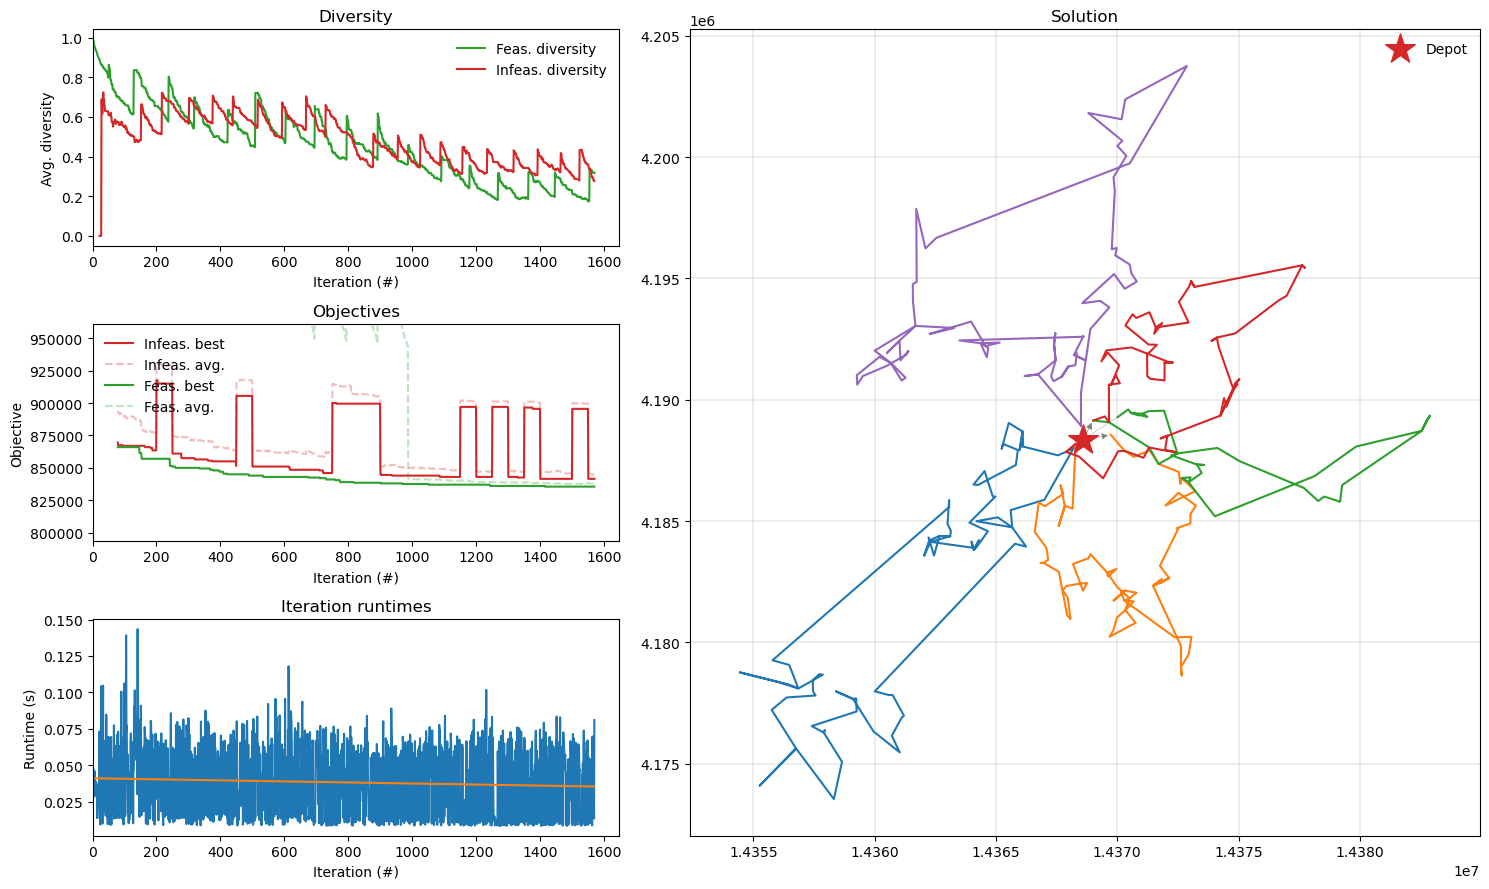

In [3]:
from pyvrp.plotting import plot_result

fig = plt.figure(figsize=(15, 9))
plot_result(res, m.data(), fig)
fig.tight_layout()

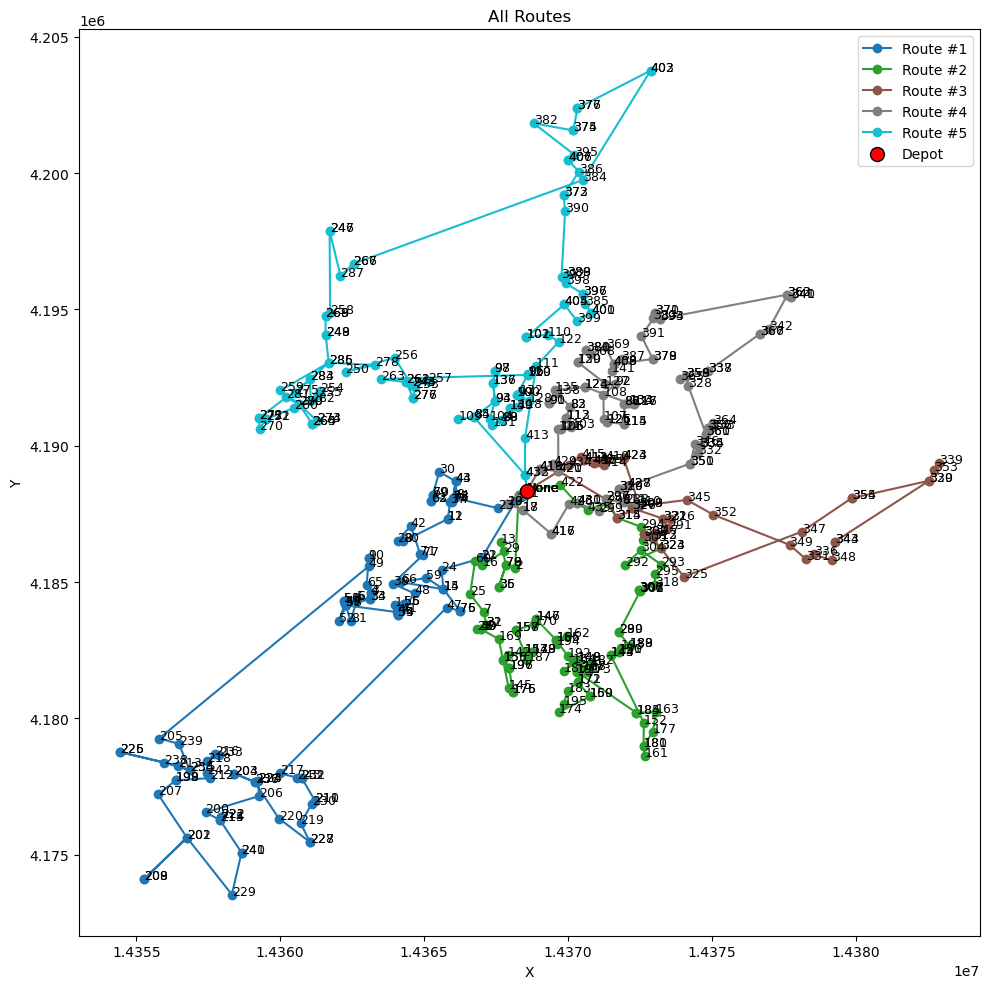

In [5]:
import matplotlib.pyplot as plt
import matplotlib

routes = [list(route) for route in res.best.routes()]
coords_np = np.array(coords)

plt.figure(figsize=(10, 10))
num_routes = len(routes)
colors = matplotlib.colormaps['tab10'].resampled(num_routes)


for idx, route in enumerate(routes):

    route_with_depot = [0] + route + [0]
    route_coords = coords_np[route_with_depot]

    plt.plot(route_coords[:, 0], route_coords[:, 1], marker='o', label=f'Route #{idx+1}', color=colors(idx))
    for i, node_idx in enumerate(route_with_depot):
        #plt.annotate(f'{index_to_location_name[node_idx]}', (route_coords[i, 0], route_coords[i, 1]), fontsize=9)
        plt.annotate(f'{index_to_order_number[node_idx]}', (route_coords[i, 0], route_coords[i, 1]), fontsize=9) # this also works 
plt.scatter(coords_np[0, 0], coords_np[0, 1], c='red', s=100, label='Depot', edgecolors='black', zorder=5)

plt.title("All Routes")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
new_df = df.clear()
for i in range(len(routes)):
    order_map = {order_num: idx for idx, order_num in enumerate(routes[i])}

    filtered_df = (df
        .filter(pl.col('Order_Number').is_in(routes[i]))
        .with_columns(
            pl.col('Order_Number').map_elements(
                lambda x: order_map.get(x, float('inf')), 
                return_dtype=pl.Int64
            ).alias('route_order')
        )
        .sort('route_order')
        .drop('route_order')
    )

    depot_row = pl.DataFrame({
        col: [None] if col != 'Destination' else ['Depot'] 
        for col in filtered_df.columns
    }).cast(dict(zip(filtered_df.columns, filtered_df.dtypes)))

    result = pl.concat([
        depot_row,           
        filtered_df,       
        depot_row          
    ])

    result = result.with_columns(
        (pl.int_range(pl.len())+ 1 ).alias('Route_Order')
    )

    result = result.with_columns(
        pl.lit(i).alias('Vehicle_ID').cast(pl.Int64)
    )
    new_df = pl.concat([new_df, result])
new_df.write_csv('/Users/jameslee/cj/cj_challenge/route_optimization/routes_df.csv')